# tap.overdrive~ — voiced feedback overdrive verification

`tap.overdrive~` is the spiritual successor to the Jamoma-era object of the same name —
deliberately *not* a port. TTOverdrive's memoryless odd-function curves are replaced by a
soft clipper inside a **lowpass feedback loop** (solved zero-delay, the `svf.h` /
`ladder.h` one-pass scheme), chasing the class of TS-lineage feedback pedals (the Mad
Professor Little Green Wonder was the listening reference). This notebook drives the
*shipping* kernel (`overdrive.h`, via the C ABI) and verifies the design goals from the
overdrive handoff brief:

1. **Frequency-dependent gain** — bass pinned near-clean, mids take the full drive, and
   the tilt grows with the drive setting (a static shaper cannot do this);
2. **A transfer that never flattens** — the unity clean-through path keeps output rising;
3. **Even harmonics from `asymmetry`** — absent at 0, dialable warmth above it;
4. **Oversampling** — the alias floor drops while the harmonics stay put;
5. **`body` voicing** — the pre/post EQ tilt that carries the pedal's signature;
6. **DC safety** — asymmetric clipping generates DC and the built-in blocker removes it.

Each claim here is also pinned by the kernel's Catch2 suite (`tests/overdrive_test.cpp`);
the notebook is the *measured picture* of the same behavior.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

import taptools_py as tap

plt.rcParams.update({
    "figure.dpi": 96, "figure.figsize": (9, 3.2),
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 10, "axes.labelsize": 9,
    "xtick.labelsize": 8, "ytick.labelsize": 8, "legend.fontsize": 8,
})
PAL = tap.PALETTE
fs = 48000


def tone(f, amp, seconds):
    t = np.arange(int(seconds * fs)) / fs
    return amp * np.sin(2 * np.pi * f * t)


def level(y, f):
    """Hann-windowed single-frequency amplitude (numpy Goertzel)."""
    n = len(y)
    t = np.arange(n) / fs
    win = np.hanning(n)
    return 2.0 * np.abs(np.dot(y * win, np.exp(-2j * np.pi * f * t))) / win.sum()


def gain_db(f, amp=5e-4, settle=0.25, meas=0.5, **params):
    """Small-signal gain (dB) at probe frequency f for a fresh kernel with `params`."""
    o = tap.Overdrive(fs, **params)
    x = tone(f, amp, settle + meas)
    y = o.process(x)
    n0 = int(settle * fs)
    return 20 * np.log10(level(y[n0:], f) / level(x[n0:], f))


def spectrum_db(y, ref=None):
    win = np.hanning(len(y))
    mag = np.abs(np.fft.rfft(y * win)) / (win.sum() / 2)
    freqs = np.fft.rfftfreq(len(y), 1 / fs)
    ref = ref if ref is not None else mag.max()
    return freqs, 20 * np.log10(np.maximum(mag / ref, 1e-9))


## 1. The headline: gain tilts with frequency, and the tilt grows with drive

Small-signal gain across the band at three drive settings. The feedback loop pins the
low-frequency loop gain (`k_lf_gain`) regardless of drive while mids and highs see the
full shaper gain, so the response tilts — and the tilt *grows* as drive rises. This is
the TS-lineage trait (bass stays tight and clean, mids break up first) that a memoryless
waveshaper applied to the full spectrum structurally cannot produce: its small-signal
gain is one number, flat.


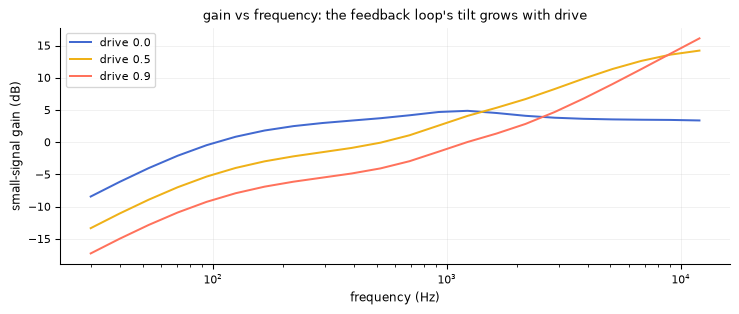

drive 0.0: gain(4 kHz) - gain(80 Hz) = +5.0 dB
drive 0.5: gain(4 kHz) - gain(80 Hz) = +16.3 dB
drive 0.9: gain(4 kHz) - gain(80 Hz) = +17.2 dB


In [2]:
freqs = np.geomspace(30, 12000, 22)
fig, ax = plt.subplots()
tilts = {}
for i, drive in enumerate((0.0, 0.5, 0.9)):
    g = np.array([gain_db(f, drive=drive) for f in freqs])
    ax.semilogx(freqs, g, color=PAL[i], label=f"drive {drive}")
    tilts[drive] = gain_db(4000, drive=drive) - gain_db(80, drive=drive)
ax.set(xlabel="frequency (Hz)", ylabel="small-signal gain (dB)",
       title="gain vs frequency: the feedback loop's tilt grows with drive")
ax.legend()
plt.show()
for d, t in tilts.items():
    print(f"drive {d}: gain(4 kHz) - gain(80 Hz) = {t:+.1f} dB")


## 2. The transfer never flattens

Peak output versus peak input at rising drive. The `shape()` curve is asymptotic to ±1,
but the unity clean path summed around the clipper (the non-inverting op-amp topology)
keeps the total transfer rising with reduced slope — no hard plateau, which is a large
part of why the old sine-shaper mode read as "digital".


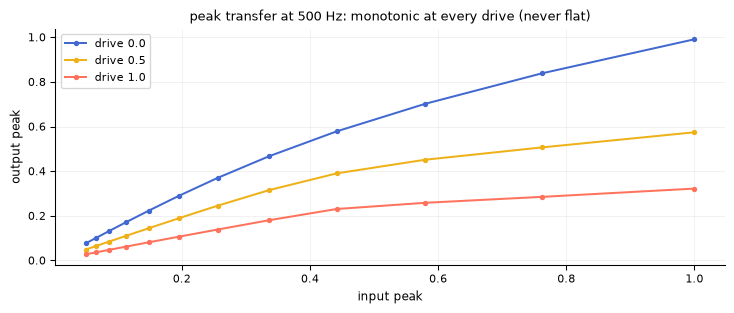

output peak strictly increases with input at every drive setting


In [3]:
amps = np.geomspace(0.05, 1.0, 12)
fig, ax = plt.subplots()
for i, drive in enumerate((0.0, 0.5, 1.0)):
    peaks = []
    for amp in amps:
        o = tap.Overdrive(fs, drive=drive)
        y = o.process(tone(500, amp, 0.75))
        peaks.append(np.abs(y[int(0.25 * fs):]).max())
    ax.plot(amps, peaks, "o-", ms=3, color=PAL[i], label=f"drive {drive}")
    assert np.all(np.diff(peaks) > 0), "transfer flattened"
ax.set(xlabel="input peak", ylabel="output peak",
       title="peak transfer at 500 Hz: monotonic at every drive (never flat)")
ax.legend()
plt.show()
print("output peak strictly increases with input at every drive setting")


## 3. Even harmonics appear with asymmetry — and are absent without it

At `asymmetry 0` the whole path is odd-symmetric: odd harmonics only, like both Jamoma
modes. Raising `asymmetry` biases the clipper and the even series appears — the
"warmth" vocabulary the old object structurally lacked. The DC that the bias generates
is removed by the built-in blocker (section 6).


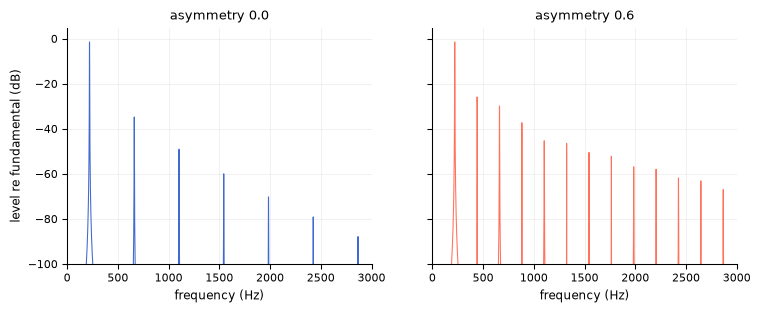

H2 relative to H1:  asymmetry 0.0 -> -151 dB   asymmetry 0.6 -> -26 dB


In [4]:
f0 = 220.5
fig, axes = plt.subplots(1, 2, figsize=(9, 3.2), sharey=True)
h2 = {}
for ax, asym, ci in ((axes[0], 0.0, 0), (axes[1], 0.6, 2)):
    o = tap.Overdrive(fs, drive=0.6, asymmetry=asym)
    y = o.process(tone(f0, 0.5, 1.5))[int(0.5 * fs):]
    fr, db = spectrum_db(y, ref=level(y, f0))
    ax.plot(fr, db, color=PAL[ci], lw=0.8)
    ax.set(xlim=(0, 3000), ylim=(-100, 5), xlabel="frequency (Hz)",
           title=f"asymmetry {asym}")
    h2[asym] = 20 * np.log10(level(y, 2 * f0) / level(y, f0))
axes[0].set_ylabel("level re fundamental (dB)")
plt.show()
print(f"H2 relative to H1:  asymmetry 0.0 -> {h2[0.0]:.0f} dB   asymmetry 0.6 -> {h2[0.6]:.0f} dB")


The second harmonic is dialable — near the measurement floor at 0, rising smoothly with
the control:


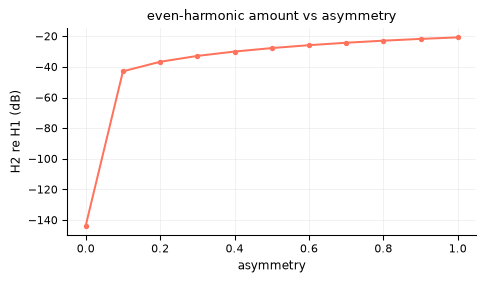

In [5]:
asyms = np.linspace(0, 1, 11)
h2_curve = []
for a in asyms:
    o = tap.Overdrive(fs, drive=0.6, asymmetry=a)
    y = o.process(tone(f0, 0.5, 1.0))[int(0.25 * fs):]
    h2_curve.append(20 * np.log10(level(y, 2 * f0) / level(y, f0)))
fig, ax = plt.subplots(figsize=(5.5, 2.8))
ax.plot(asyms, h2_curve, "o-", ms=3, color=PAL[2])
ax.set(xlabel="asymmetry", ylabel="H2 re H1 (dB)", title="even-harmonic amount vs asymmetry")
plt.show()


## 4. Oversampling drops the alias floor and leaves the harmonics alone

A 5001 Hz tone at drive 0.9. At 1× the clipper's upper harmonics fold straight back into
the audio band (H7 lands at 12993 Hz); at the default 4× they are generated at 192 kHz
and filtered before decimation. The true harmonics (10002, 15003, 20004 Hz) stay put.


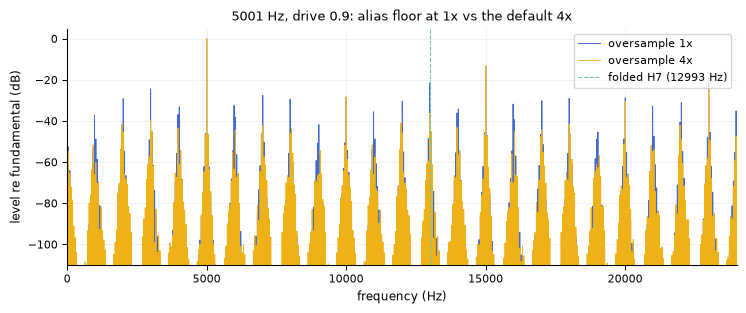

folded H7: -22 dB at 1x -> -36 dB at 4x (15 dB improvement)


In [6]:
f0a = 5001.0
alias_f = fs - 7 * f0a  # H7 folded at 1x
fig, ax = plt.subplots()
alias_rel = {}
for i, os_ in enumerate((1, 4)):
    o = tap.Overdrive(fs, drive=0.9, asymmetry=0.2, oversample=os_)
    y = o.process(tone(f0a, 0.6, 1.5))[int(0.5 * fs):]
    fr, db = spectrum_db(y, ref=level(y, f0a))
    ax.plot(fr, db, lw=0.7, color=PAL[i], label=f"oversample {os_}x")
    alias_rel[os_] = 20 * np.log10(level(y, alias_f) / level(y, f0a))
ax.axvline(alias_f, color=PAL[3], lw=0.8, ls="--", label="folded H7 (12993 Hz)")
ax.set(xlim=(0, fs / 2), ylim=(-110, 5), xlabel="frequency (Hz)",
       ylabel="level re fundamental (dB)",
       title="5001 Hz, drive 0.9: alias floor at 1x vs the default 4x")
ax.legend()
plt.show()
print(f"folded H7: {alias_rel[1]:.0f} dB at 1x -> {alias_rel[4]:.0f} dB at 4x "
      f"({alias_rel[1] - alias_rel[4]:.0f} dB improvement)")


## 5. body — the voicing control

`body` is linear pre/post EQ around the clipper, not part of the nonlinearity. Toward
−1 the pre-clipper highpass corner drops (fuller lows reach the clipper) and a slight
treble shelf lifts the top; toward +1 the lows thin and tighten and an upper-mid bell
(centered at 1150 Hz — deliberately above the classic TS hump) pushes forward. The
voicing constants are by-ear placeholders pending the in-Max pass against LGW demos —
this plot is the shape of the control, not its final tuning.


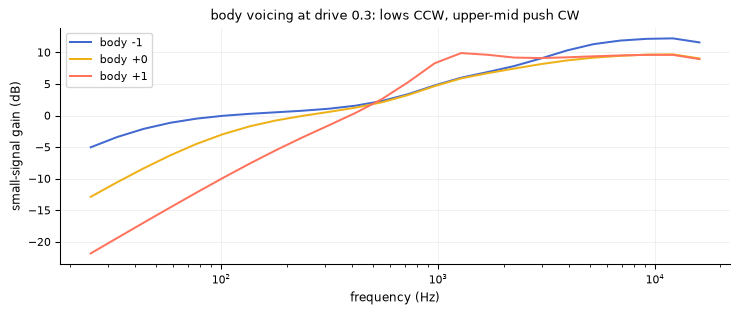

100 Hz:   body -1 vs +1 -> +10.0 dB
1150 Hz:  body +1 vs -1 -> +4.0 dB
8 kHz:    body -1 vs 0  -> +2.5 dB


In [7]:
freqs_b = np.geomspace(25, 16000, 24)
fig, ax = plt.subplots()
for i, body in enumerate((-1.0, 0.0, 1.0)):
    g = np.array([gain_db(f, drive=0.3, body=body) for f in freqs_b])
    ax.semilogx(freqs_b, g, color=PAL[i], label=f"body {body:+.0f}")
ax.set(xlabel="frequency (Hz)", ylabel="small-signal gain (dB)",
       title="body voicing at drive 0.3: lows CCW, upper-mid push CW")
ax.legend()
plt.show()
print(f"100 Hz:   body -1 vs +1 -> {gain_db(100, drive=0.3, body=-1.0) - gain_db(100, drive=0.3, body=1.0):+.1f} dB")
print(f"1150 Hz:  body +1 vs -1 -> {gain_db(1150, drive=0.3, body=1.0) - gain_db(1150, drive=0.3, body=-1.0):+.1f} dB")
print(f"8 kHz:    body -1 vs 0  -> {gain_db(8000, drive=0.3, body=-1.0) - gain_db(8000, drive=0.3, body=0.0):+.1f} dB")


## 6. Asymmetric clipping makes DC; the blocker removes it

With the blocker in the path (always on — `R = 0.9997`, the Jamoma TTDCBlock constant)
the output mean stays at zero even at full drive and full asymmetry. The old
TTOverdrive had a DC blocker object but wired it so its output was discarded; here it
is load-bearing, since the feedback one-pole would otherwise integrate the offset.


In [8]:
means = []
for a in (0.0, 0.5, 1.0):
    o = tap.Overdrive(fs, drive=1.0, asymmetry=a)
    y = o.process(tone(100, 0.8, 2.0))[fs:]  # exactly 100 periods
    means.append(np.mean(y))
    print(f"asymmetry {a}: output mean = {np.mean(y):+.2e}")
assert all(abs(m) < 5e-3 for m in means)


asymmetry 0.0: output mean = +1.66e-12
asymmetry 0.5: output mean = -3.22e-10
asymmetry 1.0: output mean = -7.02e-10


## Summary

- The feedback loop delivers the frequency-dependent gain the brief asked for: flat at
  minimum drive, tens of dB of bass-vs-mid tilt at high drive, growing monotonically.
- The transfer is monotonic at every drive — the clean-through path keeps it from ever
  flattening into the plateau that made the old sine shaper read as digital.
- Even harmonics are absent at `asymmetry 0` and dialable above it.
- The default 4× oversampling buys a measurably lower alias floor with the true
  harmonics unchanged.
- `body` reshapes lows/upper-mids/top as designed (final tuning belongs to the by-ear
  voicing pass).
- The always-on DC blocker holds the mean at zero under the heaviest asymmetric
  clipping.

The same claims are pinned as hard assertions in the kernel suite
(`tests/overdrive_test.cpp`), so CI guards them from regressing.
